Available data and deciding study period

In [2]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/home/py/groundwater")
DATA = PROJECT_ROOT / "data" / "gown"
PQ_ACTIVE = DATA / "parquet" / "active"

In [3]:
stations = pd.read_csv(DATA / "tables" / "stations.csv", dtype={"gown": str})
stations = stations.set_index(stations["gown"].str.zfill(4))

In [4]:
def months_present(path: Path) -> set:
    s = pd.read_parquet(path, columns=["absolute_value"])["absolute_value"].dropna()
    return set(s.index.tz_localize(None).to_period("M"))

present = {p.stem: months_present(p) for p in sorted(PQ_ACTIVE.glob("*.parquet"))}
len(present)

304

In [5]:
all_months = pd.period_range(
    min(m for v in present.values() for m in v),
    max(m for v in present.values() for m in v),
    freq="M",
)

presence = pd.DataFrame(
    {g: [m in v for m in all_months] for g, v in present.items()},
    index=all_months,
).T   # rows = wells, columns = year-month

presence.shape

(304, 828)

<Axes: title={'center': 'Active wells reporting, by month'}>

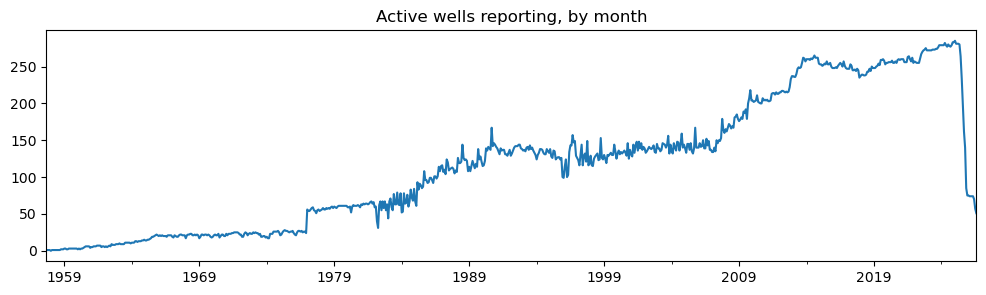

In [6]:
wells_per_month = presence.sum(axis=0)
wells_per_month.plot(figsize=(12, 3), title="Active wells reporting, by month")

In [7]:
def coverage_between(start: str, end: str) -> pd.DataFrame:
    """Per-well presence between two year-months (inclusive), plus summary counts."""
    months = pd.period_range(start, end, freq="M")
    sub = presence.reindex(columns=months, fill_value=False)

    per_well = pd.DataFrame({
        "months_present": sub.sum(axis=1),
        "months_missing": len(months) - sub.sum(axis=1),
        "coverage": sub.sum(axis=1) / len(months),
    })
    per_well = per_well.join(stations[["station_name"]], how="left")

    unmatched = per_well["station_name"].isna().sum()
    if unmatched:
        print(f"warning: {unmatched} gown # not found in stations.csv")

    print(f"{start} to {end}  ({len(months)} months)")
    print(f"stations with any data: {(per_well.months_present > 0).sum()} / {len(per_well)}")
    print(f"stations with full coverage: {(per_well.coverage == 1.0).sum()}")
    print(f"average missing: {per_well.months_missing.mean():.1f} months "
          f"({1 - per_well.coverage.mean():.1%})")

    return per_well.sort_values("coverage")


START, END = "2005-01", "2024-12"
cov = coverage_between(START, END)
cov

2005-01 to 2024-12  (240 months)
stations with any data: 305 / 305
stations with full coverage: 40
average missing: 62.2 months (25.9%)


,months_present,months_missing,coverage,station_name
0332,1,239,0.004167,Sion #3_0332
0472,3,237,0.012500,Iron River Stainless Steel_0472
3099,4,236,0.016667,Lac La Biche North_3099
3073,6,234,0.025000,Moose Lake_3073
3072,6,234,0.025000,Whitney Lake_3072
...,...,...,...,...
0109,240,0,1.000000,Lethbridge Airport_0109
0101,240,0,1.000000,Del Bonita 70-3_0101
0102,240,0,1.000000,Cressday 85-2_0102
0105,240,0,1.000000,Waterton Dam #5_0105


In [10]:
THRESHOLD = 0.8

ab_cov = cov[cov["coverage"] > THRESHOLD]
print(f"{len(ab_cov)} / {len(cov)} wells above {THRESHOLD:.0%} coverage")
ab_cov

166 / 305 wells above 80% coverage


,months_present,months_missing,coverage,station_name
0411,195,45,0.812500,Cadotte Lake 2443E_0411
0947,197,43,0.820833,Kehiwin Lake 07-07_0947
0793,197,43,0.820833,Pine Coulee 23D_0793 - AGI
0165,201,39,0.837500,Vegreville Environment Center 85-2 Middle_0165
0310,203,37,0.845833,Warburg 2178E_0310
...,...,...,...,...
0109,240,0,1.000000,Lethbridge Airport_0109
0101,240,0,1.000000,Del Bonita 70-3_0101
0102,240,0,1.000000,Cressday 85-2_0102
0105,240,0,1.000000,Waterton Dam #5_0105


In [13]:
def load_daily(gown: str) -> pd.Series:
    s = pd.read_parquet(PQ_ACTIVE / f"{gown}.parquet", columns=["value"])["value"]
    s.index = s.index.tz_localize(None)
    return s.resample("D").mean()   # collapses sub-daily readings, leaves gap-days as NaN

series = {}
for gown in ab_cov.index:
    s = load_daily(gown).loc[f"{START}-01":f"{END}-31"]
    if not s.empty:
        series[gown] = s

combined = pd.DataFrame(series)
combined.index.name = "date"
combined.to_csv(DATA / "combined_mbtoc.csv")
combined.shape

(7305, 166)

In [14]:
def load_daily_abs(gown: str) -> pd.Series:
    s = pd.read_parquet(PQ_ACTIVE / f"{gown}.parquet", columns=["absolute_value"])["absolute_value"]
    s.index = s.index.tz_localize(None)
    return s.resample("D").mean()   # collapses sub-daily readings, leaves gap-days as NaN

series = {}
for gown in ab_cov.index:
    s = load_daily_abs(gown).loc[f"{START}-01":f"{END}-31"]
    if not s.empty:
        series[gown] = s

combined = pd.DataFrame(series)
combined.index.name = "date"
combined.to_csv(DATA / "combined_absval.csv")
combined.shape

(7305, 166)